In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
# Customer data
data = {
    "CustomerID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Annual_Income": [15, 25, 45, 55, 65, 75, 85, 95, 105, 120],
    "Spending_Score": [39, 81, 62, 23, 95, 44, 35, 75, 15, 50]
}

df = pd.DataFrame(data)
df


,CustomerID,Annual_Income,Spending_Score
0,1,15,39
1,2,25,81
2,3,45,62
3,4,55,23
4,5,65,95
5,6,75,44
6,7,85,35
7,8,95,75
8,9,105,15
9,10,120,50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      10 non-null     int64
 1   Annual_Income   10 non-null     int64
 2   Spending_Score  10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes
None
       CustomerID  Annual_Income  Spending_Score
count    10.00000      10.000000       10.000000
mean      5.50000      68.500000       51.900000
std       3.02765      34.160569       25.937746
min       1.00000      15.000000       15.000000
25%       3.25000      47.500000       36.000000
50%       5.50000      70.000000       47.000000
75%       7.75000      92.500000       71.750000
max      10.00000     120.000000       95.000000


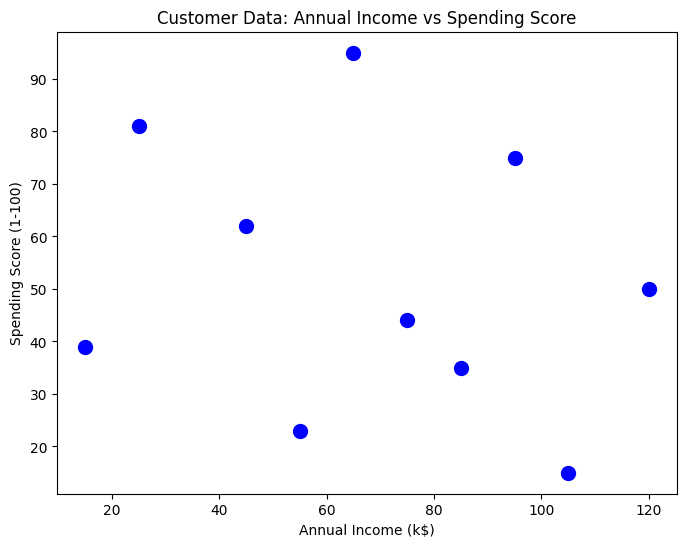

In [3]:
print(df.info())
print(df.describe())

# Scatter plot of data
plt.figure(figsize=(8,6))
plt.scatter(df["Annual_Income"], df["Spending_Score"], s=100, color="blue")
plt.title("Customer Data: Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()


In [4]:
scaler = StandardScaler()
X = df[["Annual_Income", "Spending_Score"]]
X_scaled = scaler.fit_transform(X)


In [6]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df["Cluster"] = clusters


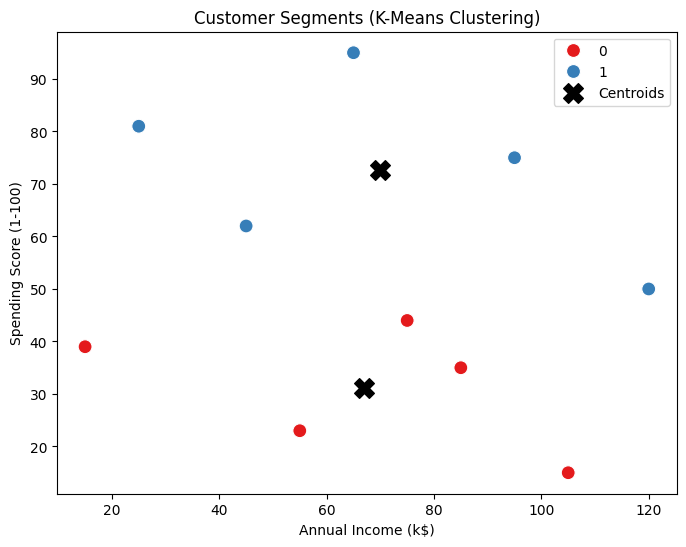

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score", hue="Cluster", palette="Set1", s=100)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c="black", s=200, marker="X", label="Centroids")

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()


In [8]:
print(df[["CustomerID", "Annual_Income", "Spending_Score", "Cluster"]])


   CustomerID  Annual_Income  Spending_Score  Cluster
0           1             15              39        0
1           2             25              81        1
2           3             45              62        1
3           4             55              23        0
4           5             65              95        1
5           6             75              44        0
6           7             85              35        0
7           8             95              75        1
8           9            105              15        0
9          10            120              50        1


Result Explanation:

Customers have been grouped into 2 clusters based on annual income and spending score.

Clusters are visualized in different colors.

Centroids (black X) show the center of each cluster.